In [34]:
import pandas as pd
import os
import glob

def consolidate_results():
    base_dir = 'results_alphaFold'
    folders = [
        os.path.join(base_dir, 'metrics_results'),
        os.path.join(base_dir, 'results_random')
    ]
    
    individual_indices = [1, 15, 30, 45, 60, 75, 90]
    dataframes = []

    # Process AlphaFold results
    for folder in folders:
        if not os.path.exists(folder):
            print(f"Warning: Folder '{folder}' does not exist. Skipping...")
            continue
            
        csv_files = glob.glob(os.path.join(folder, '*.csv'))
        
        for file in csv_files:
            filename = os.path.basename(file)
            name_no_ext = filename.replace('.csv', '')
            
            if name_no_ext.startswith('results_blosum62_fitness_auc_pr_'):
                model = 'blosum62_fitness_auc_pr'
                peptide = name_no_ext.replace('results_blosum62_fitness_auc_pr_', '')
                
            elif 'shannon_entropy' in name_no_ext:
                model = 'blosum62_fitness_shannon_entropy'
                peptide = name_no_ext.split('entropy_')[-1]
                
            elif name_no_ext.startswith('results_random_'):
                model = 'random'
                peptide = name_no_ext.replace('results_random_', '')
                
            else:
                parts = name_no_ext.split('_')
                peptide = parts[-1]
                model = "_".join(parts[1:-1])

            try:
                df = pd.read_csv(file)
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                continue
            
            if len(df) == 7:
                df['individual'] = individual_indices
            else:
                df['individual'] = range(1, len(df) + 1)
                
            df['model'] = model
            df['peptide'] = peptide
            dataframes.append(df)

    if not dataframes:
        print("No CSV files were found for processing.")
        return None

    df_final = pd.concat(dataframes, ignore_index=True)

    # Process ESM2 fitness data
    esm2_base_dir = 'results_esm2'
    esm2_models = ['blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
    esm2_data_list = []

    print("Processing ESM2 fitness data...")
    for algo in esm2_models:
        algo_path = os.path.join(esm2_base_dir, algo)
        if not os.path.exists(algo_path):
            continue

        esm2_files = glob.glob(os.path.join(algo_path, 'genetic_results_esm2_*.csv'))
        
        for file in esm2_files:
            filename = os.path.basename(file)
            peptide = filename.replace('genetic_results_esm2_', '').replace('.csv', '')
            
            try:
                df_esm = pd.read_csv(file)
                df_esm['individual'] = range(1, len(df_esm) + 1)
                df_esm['model'] = algo
                df_esm['peptide'] = peptide
                
                esm2_data_list.append(df_esm[['peptide', 'model', 'individual', 'fitness']])
            except Exception as e:
                print(f"Error reading ESM2 file {filename}: {e}")

    # Merge results
    if esm2_data_list:
        df_esm2_all = pd.concat(esm2_data_list, ignore_index=True)
        
        df_final = pd.merge(
            df_final, 
            df_esm2_all, 
            on=['peptide', 'model', 'individual'], 
            how='left'
        )
    else:
        print("Warning: No ESM2 fitness data found to merge.")
        df_final['fitness'] = None

    # Reorder columns
    base_columns = ['peptide', 'model', 'individual', 'fitness']
    base_columns = [c for c in base_columns if c in df_final.columns]
    other_columns = [col for col in df_final.columns if col not in base_columns]
    df_final = df_final[base_columns + other_columns]
    
    # Save output
    output_path = os.path.join(os.getcwd(), 'consolidated_results.csv')
    df_final.to_csv(output_path, index=False)
    
    print(f"Consolidated file created at: {output_path}")
    print(f"Total files processed: {len(dataframes)}")
    
    return df_final

In [35]:
results = consolidate_results()

Processing ESM2 fitness data...
Consolidated file created at: /home/biocomp/Documents/Jazmin/consolidated_results.csv
Total files processed: 93


In [36]:
# Check if there are duplicated sequences
num_sequences = results['sequence'].value_counts() 
duplicated_sequences = num_sequences[num_sequences>1]
print(duplicated_sequences)
print(results[results.duplicated(subset=['sequence'], keep=False)].sort_values('sequence'))

Series([], Name: count, dtype: int64)
Empty DataFrame
Columns: [peptide, model, individual, fitness, sequence, dRMSD, Pearson_Correlation, GDT_TS]
Index: []


## **Diferences between algorithms**

### **Best individual per peptide**

#### Friendman's test for GDT_TS and dRMSD

In [37]:
results.columns

Index(['peptide', 'model', 'individual', 'fitness', 'sequence', 'dRMSD',
       'Pearson_Correlation', 'GDT_TS'],
      dtype='object')

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import friedmanchisquare

color_random = "#F0E491"
color_auc = "#B8DB80"
color_shannon = "#E9C46A"
algo_order = ['random', 'blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
custom_palette = [color_random, color_auc, color_shannon] 


In [39]:
def get_best(metric_name):
    if metric_name == "GDT_TS":
        idx_best = results.groupby(['peptide', 'model'])[metric_name].idxmax()
    elif metric_name == "dRMSD":
        idx_best = results.groupby(['peptide', 'model'])[metric_name].idxmin()
    best_all = results.loc[idx_best].copy()
    return best_all

## dRSMD

In [40]:
best_all = get_best("dRMSD")
print(best_all.sort_values('dRMSD')[['peptide', 'model', 'GDT_TS', 'dRMSD']])

    peptide                             model    GDT_TS      dRMSD
211    2oar  blosum62_fitness_shannon_entropy  1.000000   0.339521
128    3m9q  blosum62_fitness_shannon_entropy  0.955882   0.377431
314    2oar           blosum62_fitness_auc_pr  0.985294   0.382227
262    3ewk  blosum62_fitness_shannon_entropy  0.985294   0.437233
387    3ewk           blosum62_fitness_auc_pr  0.985294   0.446324
..      ...                               ...       ...        ...
538    1s7m                            random  0.116071   8.327638
555    3e7r                            random  0.116667   8.484484
619    1lql                            random  0.038462   8.607592
401    1o6w           blosum62_fitness_auc_pr  0.153846   9.258202
413    1aay           blosum62_fitness_auc_pr  0.144231  10.525043

[93 rows x 4 columns]


In [41]:
df_pivot_rms = best_all.pivot(index='peptide', columns='model', values='dRMSD')

algorithms = df_pivot_rms.columns.tolist()
n_peptides = len(df_pivot_rms)

stat_rms, p_rms = friedmanchisquare(
        *[df_pivot_rms[algo] for algo in algorithms]
    )
print(f"\nFriedman Test for dRMSD: Statistic={stat_rms}, p-value={p_rms}")


Friedman Test for dRMSD: Statistic=7.806451612903231, p-value=0.02017672016103374


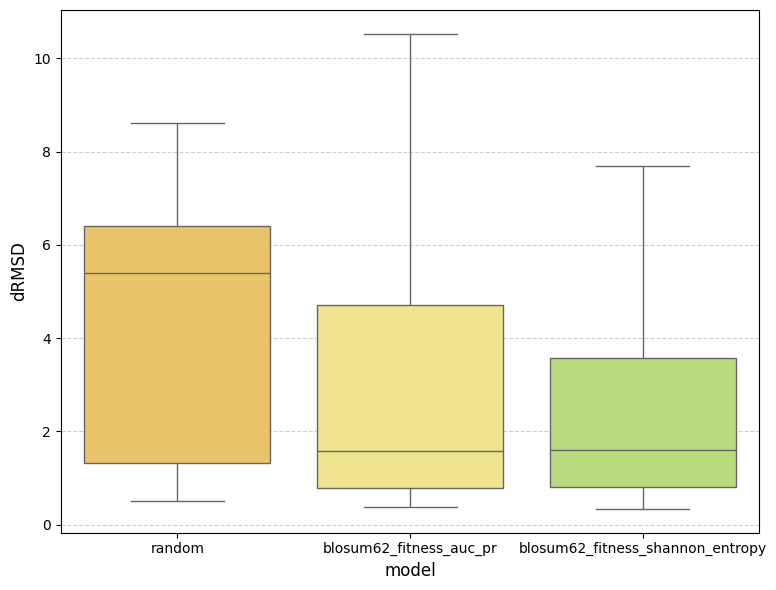

In [42]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=best_all, 
    x='model', 
    y='dRMSD',
    hue='model' ,
    order=algo_order,
    palette=custom_palette, 
    saturation=1,
    linewidth=1,
    flierprops=dict(marker='*', markerfacecolor='gold', markersize=8)
)

plt.xlabel('model', fontsize=12)
plt.ylabel('dRMSD', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#dRMSD_Algorithms

## GDT TS

In [43]:
best_all = get_best("GDT_TS")
print(best_all.sort_values('GDT_TS')[['peptide', 'model', 'GDT_TS', 'dRMSD']])

df_pivot_gdt = best_all.pivot(index='peptide', columns='model', values='GDT_TS')

algorithms = df_pivot_gdt.columns.tolist()
n_peptides = len(df_pivot_gdt)

stat_gdt, p_gdt = friedmanchisquare(
        *[df_pivot_gdt[algo] for algo in algorithms]
    )

print(f"\nFriedman Test for GDT_TS: Statistic={stat_gdt}, p-value={p_gdt}")

    peptide                             model    GDT_TS      dRMSD
621    1lql                            random  0.086538   8.746018
538    1s7m                            random  0.116071   8.327638
437    1aay                            random  0.144231   7.414990
413    1aay           blosum62_fitness_auc_pr  0.144231  10.525043
406    1o6w  blosum62_fitness_shannon_entropy  0.144231   7.913467
..      ...                               ...       ...        ...
387    3ewk           blosum62_fitness_auc_pr  0.985294   0.446324
260    3ewk  blosum62_fitness_shannon_entropy  0.985294   0.510472
560    2oar                            random  0.985294   0.598092
211    2oar  blosum62_fitness_shannon_entropy  1.000000   0.339521
308    2oar           blosum62_fitness_auc_pr  1.000000   0.395746

[93 rows x 4 columns]

Friedman Test for GDT_TS: Statistic=14.939130434782568, p-value=0.0005701761456656246


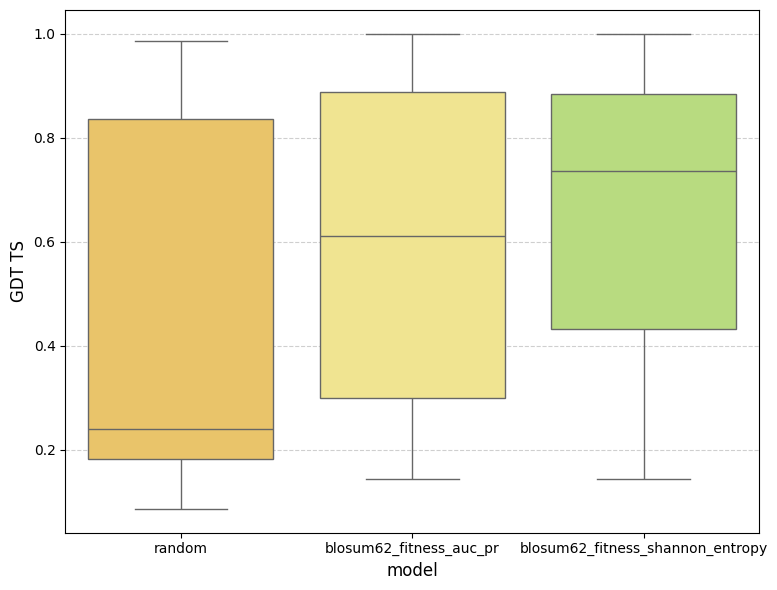

In [44]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=best_all, 
    x='model', 
    y='GDT_TS',
    hue='model' ,
    order=algo_order,
    palette=custom_palette, 
    saturation=1,
    linewidth=1,
    flierprops=dict(marker='*', markerfacecolor='gold', markersize=8)
)

plt.xlabel('model', fontsize=12)
plt.ylabel('GDT TS', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
#GDT_TS_Algorithms

#### Wilcoxon test


In [45]:
from scipy.stats import wilcoxon
import pandas as pd

def run_posthoc_wilcoxon(df_best, metric_name):
    
    # 1. Pivot data to have one column per model
    # Ensure we only use rows where all algorithms have paired data
    df_pivot = df_best.pivot(index='peptide', columns='model', values=metric_name).dropna()
    
    # 2. Get list of available algorithms
    algos = df_pivot.columns.tolist()
    
    # 3. Generate all pairwise comparisons
    comparisons = []
    for i in range(len(algos)):
        for j in range(i + 1, len(algos)):
            comparisons.append((algos[i], algos[j]))
    
    # 4. Bonferroni correction setup
    alpha = 0.05
    n_comparisons = len(comparisons)
    bonferroni_alpha = alpha / n_comparisons
    
    print(f"--- POST-HOC WILCOXON TEST ---")
    print(f"Metric analyzed: {metric_name}")
    print(f"Sample size: {len(df_pivot)} peptides")
    print(f"Corrected alpha (Bonferroni): {bonferroni_alpha:.4f}\n")
    print(f"{'Comparison':<65} | {'p-value':<12} | {'Significant?'}")
    print("-" * 95)

    results_list = []

    for g1, g2 in comparisons:
        # Run paired Wilcoxon test
        stat, p = wilcoxon(df_pivot[g1], df_pivot[g2])
        
        is_significant = "YES" if p < bonferroni_alpha else "NO"
        
        print(f"{f'{g1} vs {g2}':<65} | {p:<12.2e} | {is_significant}")
        
        results_list.append({
            'comparison': f"{g1} vs {g2}",
            'p_value': p,
            'significant': is_significant
        })

    return pd.DataFrame(results_list)


In [46]:
best_all = get_best("GDT_TS")
run_posthoc_wilcoxon(best_all, "GDT_TS")

--- POST-HOC WILCOXON TEST ---
Metric analyzed: GDT_TS
Sample size: 31 peptides
Corrected alpha (Bonferroni): 0.0167

Comparison                                                        | p-value      | Significant?
-----------------------------------------------------------------------------------------------
blosum62_fitness_auc_pr vs blosum62_fitness_shannon_entropy       | 2.49e-01     | NO
blosum62_fitness_auc_pr vs random                                 | 3.60e-04     | YES
blosum62_fitness_shannon_entropy vs random                        | 1.59e-03     | YES


,comparison,p_value,significant
0,blosum62_fitness_auc_pr vs blosum62_fitness_sh...,0.248828,NO
1,blosum62_fitness_auc_pr vs random,0.000360,YES
2,blosum62_fitness_shannon_entropy vs random,0.001592,YES


In [47]:
best_all = get_best("dRMSD")
run_posthoc_wilcoxon(best_all, "dRMSD")

--- POST-HOC WILCOXON TEST ---
Metric analyzed: dRMSD
Sample size: 31 peptides
Corrected alpha (Bonferroni): 0.0167

Comparison                                                        | p-value      | Significant?
-----------------------------------------------------------------------------------------------
blosum62_fitness_auc_pr vs blosum62_fitness_shannon_entropy       | 1.41e-01     | NO
blosum62_fitness_auc_pr vs random                                 | 6.64e-02     | NO
blosum62_fitness_shannon_entropy vs random                        | 5.41e-04     | YES


,comparison,p_value,significant
0,blosum62_fitness_auc_pr vs blosum62_fitness_sh...,0.140606,NO
1,blosum62_fitness_auc_pr vs random,0.066421,NO
2,blosum62_fitness_shannon_entropy vs random,0.000541,YES


### **Best-robustness performance**

In [48]:
median_results = results.groupby(['peptide', 'model'])[['dRMSD', 'GDT_TS']].median().reset_index()
print(median_results.head())

  peptide                             model      dRMSD    GDT_TS
0    1aay           blosum62_fitness_auc_pr  11.923069  0.086538
1    1aay  blosum62_fitness_shannon_entropy   8.004978  0.115385
2    1aay                            random   8.240257  0.115385
3    1emn           blosum62_fitness_auc_pr   1.948392  0.509259
4    1emn  blosum62_fitness_shannon_entropy   5.096481  0.407407


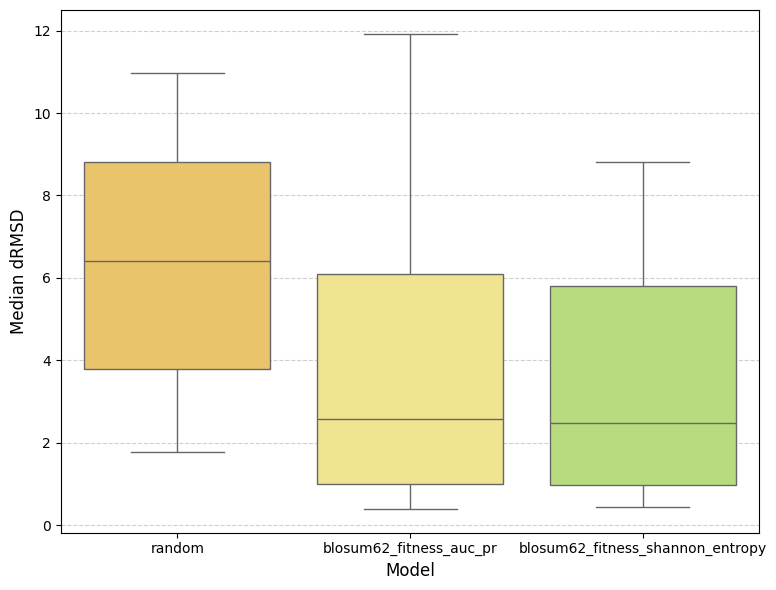

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

algo_order = ['random', 'blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
custom_palette = ["#F0E491", "#B8DB80", "#E9C46A"] 

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=median_results, 
    x='model', 
    y='dRMSD',
    hue='model',
    order=algo_order,
    palette=custom_palette, 
    saturation=1,
    linewidth=1,
    flierprops=dict(marker='*', markerfacecolor='gold', markersize=8)
)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Median dRMSD', fontsize=12)
#plt.title('Median dRMSD per Population', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Median_dRMSDper_Population

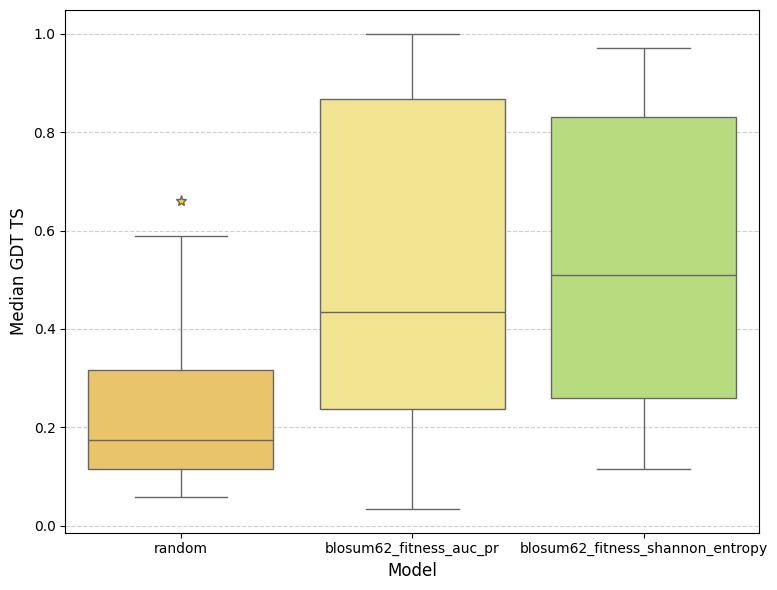

In [50]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=median_results, 
    x='model', 
    y='GDT_TS',
    hue='model',
    order=algo_order,
    palette=custom_palette, 
    saturation=1,
    linewidth=1,
    flierprops=dict(marker='*', markerfacecolor='gold', markersize=8)
)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Median GDT TS', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Median_GDT_TS_per_Population

### Friedman

In [51]:
from scipy.stats import friedmanchisquare

df_pivot_rms_med = median_results.pivot(index='peptide', columns='model', values='dRMSD')
algorithms = df_pivot_rms_med.columns.tolist()

stat_rms_med, p_rms_med = friedmanchisquare(
    *[df_pivot_rms_med[algo] for algo in algorithms]
)
print(f"Friedman Test for Median dRMSD: Statistic={stat_rms_med}, p-value={p_rms_med}")


# --- Friedman Test para Median GDT_TS ---
df_pivot_gdt_med = median_results.pivot(index='peptide', columns='model', values='GDT_TS')

stat_gdt_med, p_gdt_med = friedmanchisquare(
    *[df_pivot_gdt_med[algo] for algo in algorithms]
)
print(f"\nFriedman Test for Median GDT_TS: Statistic={stat_gdt_med}, p-value={p_gdt_med}")

Friedman Test for Median dRMSD: Statistic=17.870967741935488, p-value=0.00013163417675977443

Friedman Test for Median GDT_TS: Statistic=26.29752066115699, p-value=1.9478968019118976e-06


In [52]:
print("\\n--- POST-HOC WILCOXON TEST FOR MEDIAN dRMSD ---")
wilcoxon_dRMSD_med = run_posthoc_wilcoxon(median_results, "dRMSD")
display(wilcoxon_dRMSD_med)

print("\\n--- POST-HOC WILCOXON TEST FOR MEDIAN GDT_TS ---")
wilcoxon_GDT_med = run_posthoc_wilcoxon(median_results, "GDT_TS")
display(wilcoxon_GDT_med)

\n--- POST-HOC WILCOXON TEST FOR MEDIAN dRMSD ---
--- POST-HOC WILCOXON TEST ---
Metric analyzed: dRMSD
Sample size: 31 peptides
Corrected alpha (Bonferroni): 0.0167

Comparison                                                        | p-value      | Significant?
-----------------------------------------------------------------------------------------------
blosum62_fitness_auc_pr vs blosum62_fitness_shannon_entropy       | 5.17e-01     | NO
blosum62_fitness_auc_pr vs random                                 | 1.45e-04     | YES
blosum62_fitness_shannon_entropy vs random                        | 1.19e-05     | YES


,comparison,p_value,significant
0,blosum62_fitness_auc_pr vs blosum62_fitness_sh...,0.516765,NO
1,blosum62_fitness_auc_pr vs random,0.000145,YES
2,blosum62_fitness_shannon_entropy vs random,0.000012,YES


\n--- POST-HOC WILCOXON TEST FOR MEDIAN GDT_TS ---
--- POST-HOC WILCOXON TEST ---
Metric analyzed: GDT_TS
Sample size: 31 peptides
Corrected alpha (Bonferroni): 0.0167

Comparison                                                        | p-value      | Significant?
-----------------------------------------------------------------------------------------------
blosum62_fitness_auc_pr vs blosum62_fitness_shannon_entropy       | 7.58e-01     | NO
blosum62_fitness_auc_pr vs random                                 | 4.16e-07     | YES
blosum62_fitness_shannon_entropy vs random                        | 1.08e-05     | YES


,comparison,p_value,significant
0,blosum62_fitness_auc_pr vs blosum62_fitness_sh...,7.576704e-01,NO
1,blosum62_fitness_auc_pr vs random,4.163012e-07,YES
2,blosum62_fitness_shannon_entropy vs random,1.079626e-05,YES


## **Statistical summary**

In [53]:
import pandas as pd
import numpy as np

target_models = ['blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
metrics = ['GDT_TS', 'dRMSD', 'Pearson_Correlation']

df_filtered = results[results['model'].isin(target_models)]

summary_stats = df_filtered.groupby(['peptide', 'model'])[metrics].agg(['mean', 'std'])

def format_mean_std(row, metric):
    mean_val = row[(metric, 'mean')]
    std_val = row[(metric, 'std')]
    if pd.isna(std_val):
        std_val = 0.0
    return f"{mean_val:.3f} ± {std_val:.3f}"

summary_formatted = pd.DataFrame(index=summary_stats.index)

for metric in metrics:
    summary_formatted[metric] = summary_stats.apply(lambda row: format_mean_std(row, metric), axis=1)

table_combined = summary_formatted.unstack(level='model')

table_combined.columns.names = ['Metric', 'Model']

print("=== Combined Statistical Summary (Mean ± SD) ===")
display(table_combined)

table_combined.to_csv('combined_statistical_summary.csv')

=== Combined Statistical Summary (Mean ± SD) ===


Metric                   GDT_TS                                   \
Model   blosum62_fitness_auc_pr blosum62_fitness_shannon_entropy   
peptide                                                            
1aay              0.093 ± 0.028                    0.297 ± 0.302   
1emn              0.528 ± 0.083                    0.438 ± 0.174   
1f2i              0.198 ± 0.066                    0.246 ± 0.111   
1llm              0.153 ± 0.018                    0.643 ± 0.060   
1lql              0.740 ± 0.054                    0.791 ± 0.053   
1msl              0.542 ± 0.018                    0.401 ± 0.105   
1n7d              0.233 ± 0.055                    0.246 ± 0.057   
1np6              0.279 ± 0.014                    0.290 ± 0.080   
1o6w              0.129 ± 0.025                    0.128 ± 0.021   
1p9n              0.091 ± 0.082                    0.456 ± 0.297   
1r5l              0.343 ± 0.036                    0.217 ± 0.032   
1s7m              0.408 ± 0.049                    0.504 ± 0.013   
2e45              0.432 ± 0.224                    0.630 ± 0.346   
2i13              0.131 ± 0.016                    0.607 ± 0.262   
2kxq              0.608 ± 0.199                    0.493 ± 0.176   
2lkm              0.840 ± 0.035                    0.855 ± 0.016   
2oar              0.992 ± 0.012                    0.977 ± 0.017   
2prt              0.867 ± 0.033                    0.190 ± 0.106   
2qiw              0.870 ± 0.018                    0.776 ± 0.039   
2qq8              0.423 ± 0.036                    0.406 ± 0.043   
3c8v              0.889 ± 0.017                    0.750 ± 0.032   
3clq              0.750 ± 0.043                    0.930 ± 0.028   
3e7r              0.340 ± 0.107                    0.226 ± 0.083   
3ewk              0.981 ± 0.007                    0.935 ± 0.069   
3h25              0.868 ± 0.028                    0.914 ± 0.015   
3m9q              0.910 ± 0.079                    0.870 ± 0.158   
3sb1              0.932 ± 0.007                    0.852 ± 0.051   
3vdu              0.140 ± 0.026                    0.197 ± 0.023   
3w68              0.331 ± 0.068                    0.333 ± 0.027   
4gzn              0.273 ± 0.235                    0.332 ± 0.377   
5uiy              0.711 ± 0.011                    0.724 ± 0.011   

Metric                    dRMSD                                   \
Model   blosum62_fitness_auc_pr blosum62_fitness_shannon_entropy   
peptide                                                            
1aay             12.163 ± 1.020                    7.997 ± 5.004   
1emn              2.270 ± 0.991                    4.689 ± 2.450   
1f2i              7.455 ± 2.646                    5.779 ± 1.232   
1llm              7.172 ± 0.280                    1.951 ± 0.158   
1lql              1.217 ± 0.183                    1.094 ± 0.432   
1msl              1.909 ± 0.131                    3.138 ± 1.417   
1n7d              5.811 ± 1.101                    5.453 ± 0.790   
1np6              5.919 ± 0.577                    5.642 ± 1.013   
1o6w             10.081 ± 0.622                    8.974 ± 1.492   
1p9n             10.019 ± 4.721                    6.458 ± 7.919   
1r5l              5.087 ± 0.619                    7.054 ± 0.881   
1s7m              2.556 ± 0.257                    2.505 ± 0.047   
2e45              4.083 ± 2.636                    3.960 ± 4.032   
2i13              7.689 ± 0.139                    3.110 ± 2.602   
2kxq              2.268 ± 1.368                    3.831 ± 1.682   
2lkm              0.924 ± 0.242                    0.793 ± 0.087   
2oar              0.430 ± 0.057                    0.424 ± 0.063   
2prt              0.747 ± 0.039                    7.274 ± 1.176   
2qiw              0.873 ± 0.077                    1.044 ± 0.088   
2qq8              4.308 ± 0.468                    5.824 ± 0.443   
3c8v              0.814 ± 0.028                    1.194 ± 0.176   
3clq              1.393 ± 0.092                    0.70

## Relationship between fitness and structural quality

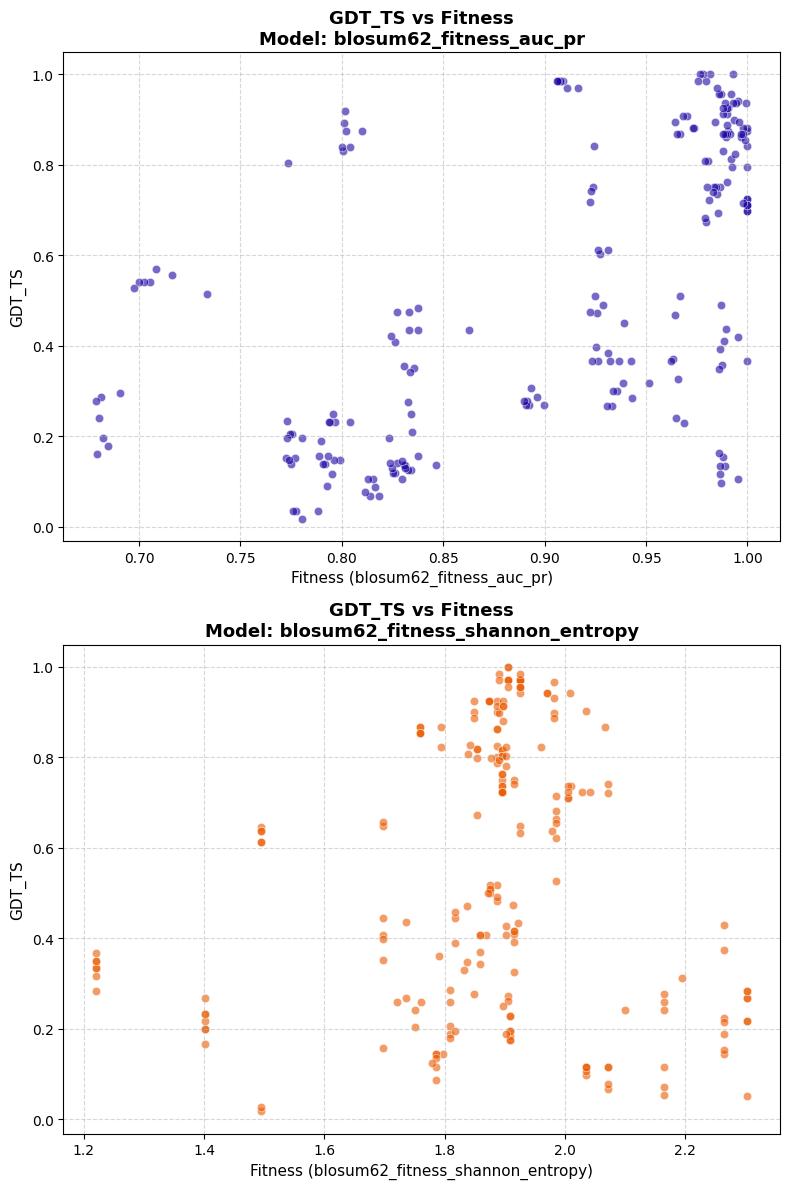

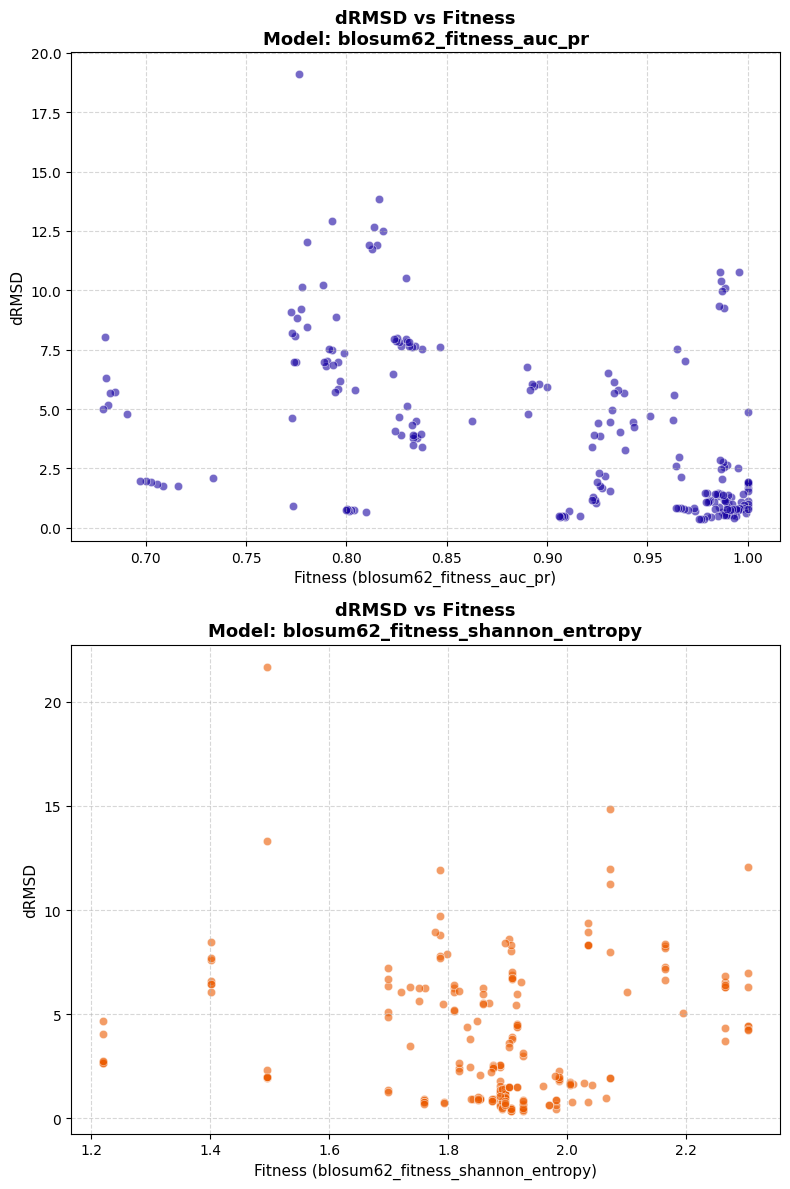

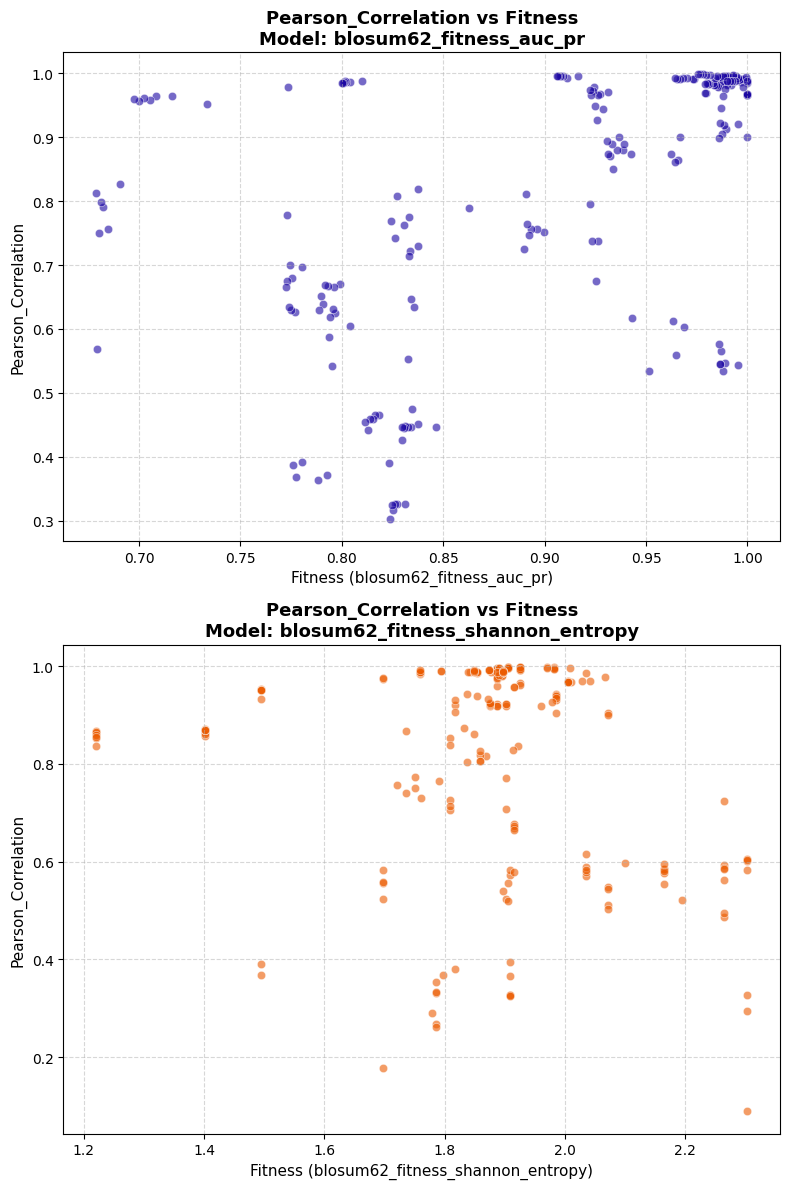

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

target_models = ['blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']

df_analysis = results[results['model'].isin(target_models)].copy()

df_analysis = df_analysis.dropna(subset=['fitness', 'GDT_TS', 'dRMSD', 'Pearson_Correlation'])

models = ['blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
metrics = ['GDT_TS', 'dRMSD', 'Pearson_Correlation']
colors = ['#1A05A2', '#EB5B00'] 

for metric in metrics:
    fig, axes = plt.subplots(2, 1, figsize=(8, 12))
    
    for j, model in enumerate(models):
        ax = axes[j]
        data_subset = df_analysis[df_analysis['model'] == model]
        
        sns.scatterplot(
            data=data_subset,
            x='fitness',
            y=metric,
            color=colors[j],
            alpha=0.6,
            ax=ax
        )
        
        ax.set_title(f'{metric} vs Fitness\nModel: {model}', fontsize=13, fontweight='bold')
        ax.set_xlabel(f'Fitness ({model})', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f'Analysis_{metric}.png')
    plt.show()



    #gdt_fitness
    #dRMSD_fitness
    #pearson_fitness

In [55]:
import pandas as pd
from scipy.stats import spearmanr

target_models = ['blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
metrics = ['GDT_TS', 'dRMSD', 'Pearson_Correlation']

df_analysis = results[results['model'].isin(target_models)].copy()

correlation_stats = []

for model in target_models:
    model_data = df_analysis[df_analysis['model'] == model].dropna(subset=['fitness'] + metrics)
    
    for metric in metrics:
        rho, p_value = spearmanr(model_data['fitness'], model_data[metric])
        
        correlation_stats.append({
            'Model': model,
            'Metric': metric,
            'Spearman_rho (ρ)': round(rho, 4),
            'p-value': f"{p_value:.2e}",
            'Significant (p < 0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

df_corr_results = pd.DataFrame(correlation_stats)
display(df_corr_results)

,Model,Metric,Spearman_rho (ρ),p-value,Significant (p < 0.05)
0,blosum62_fitness_auc_pr,GDT_TS,0.5552,6.08e-19,Yes
1,blosum62_fitness_auc_pr,dRMSD,-0.5199,2.01e-16,Yes
2,blosum62_fitness_auc_pr,Pearson_Correlation,0.5549,6.34e-19,Yes
3,blosum62_fitness_shannon_entropy,GDT_TS,0.0345,6.13e-01,No
4,blosum62_fitness_shannon_entropy,dRMSD,-0.0153,8.22e-01,No
5,blosum62_fitness_shannon_entropy,Pearson_Correlation,-0.0504,4.60e-01,No


In [56]:
import pandas as pd

def check_top1_coincidence(df):
    """
    Evaluates whether the top-1 individual selected by fitness
    coincides with the top-1 individuals selected by structural metrics.

    For each model and peptide:
    - Top-1 fitness: maximum fitness value
    - Top-1 GDT-TS: maximum structural similarity
    - Top-1 dRMSD: minimum structural deviation

    Returns a DataFrame indicating whether the fitness-selected
    individual matches the structure-optimal individuals.
    """
    
    results_list = []
    grouped = df.groupby(['model', 'peptide'])

    for (model, peptide), group in grouped:
        idx_best_fitness = group['fitness'].idxmax()
        idx_best_gdt = group['GDT_TS'].idxmax()
        idx_best_drmsd = group['dRMSD'].idxmin()

        coincides_gdt = (idx_best_fitness == idx_best_gdt)
        coincides_drmsd = (idx_best_fitness == idx_best_drmsd)

        results_list.append({
            'model': model,
            'peptide': peptide,
            'coincides_GDT_TS': coincides_gdt,
            'coincides_dRMSD': coincides_drmsd
        })

    return pd.DataFrame(results_list)


df_coincidence = check_top1_coincidence(df_analysis)

frecuencia_exito = (
    df_coincidence.groupby('model')[['coincides_GDT_TS', 'coincides_dRMSD']]
    .mean() * 100
)

print("--- TOP-1 FITNESS VS STRUCTURAL MATCH FREQUENCY (%) ---")
print(frecuencia_exito)


--- TOP-1 FITNESS VS STRUCTURAL MATCH FREQUENCY (%) ---
                                  coincides_GDT_TS  coincides_dRMSD
model                                                              
blosum62_fitness_auc_pr                  25.806452        19.354839
blosum62_fitness_shannon_entropy         29.032258        16.129032


In [59]:
best_all = get_best("GDT_TS")

# 1. Filter out the random model
target_models = ['blosum62_fitness_auc_pr', 'blosum62_fitness_shannon_entropy']
best_filtered = best_all[best_all['model'].isin(target_models)].copy()

df_formatted = best_filtered.copy()
df_formatted['GDT_formatted'] = (
    df_formatted['GDT_TS'].map('{:.4f}'.format) + 
    " (" + 
    df_formatted['individual'].astype(int).astype(str) + 
    ")"
)

summary_pivot = df_formatted.pivot(
    index='peptide', 
    columns='model', 
    values='GDT_formatted'
)

summary_pivot = summary_pivot.reset_index()
summary_pivot.columns.name = None  

summary_pivot = summary_pivot.rename(columns={
    'blosum62_fitness_auc_pr': 'AUC-PR: GDT_TS (ind)',
    'blosum62_fitness_shannon_entropy': 'Shannon: GDT_TS (ind)'
})

print(f"Final shape: {summary_pivot.shape}")
print(summary_pivot)

summary_pivot.to_csv('best_individuals_GDT_TS.csv', index=False)

Final shape: (31, 3)
   peptide AUC-PR: GDT_TS (ind) Shannon: GDT_TS (ind)
0     1aay           0.1442 (1)           0.7404 (30)
1     1emn           0.6111 (1)           0.6574 (15)
2     1f2i          0.2500 (30)           0.4286 (75)
3     1llm          0.1897 (75)           0.7155 (15)
4     1lql          0.8077 (30)           0.8269 (75)
5     1msl          0.5694 (30)            0.5000 (1)
6     1n7d           0.2946 (1)           0.3304 (15)
7     1np6          0.3056 (30)           0.4352 (75)
8     1o6w          0.1635 (90)            0.1442 (1)
9     1p9n          0.2328 (90)            0.6466 (1)
10    1r5l          0.3833 (90)           0.2667 (15)
11    1s7m          0.4911 (60)            0.5179 (1)
12    2e45           0.8804 (1)           0.9239 (60)
13    2i13          0.1562 (15)            0.8229 (1)
14    2kxq          0.8417 (15)            0.7500 (1)
15    2lkm          0.8676 (45)           0.8676 (15)
16    2oar           1.0000 (1)           1.0000 (15)
17    2

In [60]:
# Filter individuals with GDT_TS > 0.9
high_quality_auc = best_filtered[(best_filtered['model'] == 'blosum62_fitness_auc_pr') & (best_filtered['GDT_TS'] > 0.9)]
high_quality_shannon = best_filtered[(best_filtered['model'] == 'blosum62_fitness_shannon_entropy') & (best_filtered['GDT_TS'] > 0.9)]

# Print Results
print(f"Count for AUC-PR (>0.9): {len(high_quality_auc)}")
print(high_quality_auc[['peptide', 'GDT_TS', 'individual']].sort_values('GDT_TS', ascending=False))

print(f"\nCount for Shannon (>0.9): {len(high_quality_shannon)}")
print(high_quality_shannon[['peptide', 'GDT_TS', 'individual']].sort_values('GDT_TS', ascending=False))

Count for AUC-PR (>0.9): 6
    peptide    GDT_TS  individual
308    2oar  1.000000           1
387    3ewk  0.985294          30
57     3m9q  0.955882          15
175    3sb1  0.937500           1
381    2prt  0.919643          45
289    3c8v  0.907895          30

Count for Shannon (>0.9): 8
    peptide    GDT_TS  individual
211    2oar  1.000000          15
260    3ewk  0.985294          15
126    3m9q  0.970588           1
141    3clq  0.965909          15
34     3sb1  0.925000          90
421    3h25  0.925000          15
431    2e45  0.923913          60
48     4gzn  0.901786          90


In [61]:
# 1. Define the list of peptides that overlapped in the >0.9 GDT_TS results
overlapping_peptides = ['2oar', '3ewk', '3m9q', '3sb1']

# 2. Filter the dataframe to find these specific sequences for both models
winning_sequences = best_filtered[best_filtered['peptide'].isin(overlapping_peptides)]

# 3. Clean and display the results
# We sort by peptide so you can easily compare the two models side-by-side
sequence_comparison = winning_sequences[['peptide', 'model', 'GDT_TS', 'sequence']].sort_values('peptide')

print("--- SEQUENCES FOR OVERLAPPING HIGH-QUALITY PEPTIDES (>0.9 GDT_TS) ---")
display(sequence_comparison)

# 4. Optional: Save to a text file for further analysis (like ClustalW or WebLogo)
sequence_comparison.to_csv('overlapping_high_quality_sequences.csv', index=False)

--- SEQUENCES FOR OVERLAPPING HIGH-QUALITY PEPTIDES (>0.9 GDT_TS) ---


,peptide,model,GDT_TS,sequence
308,2oar,blosum62_fitness_auc_pr,1.000000,HTIFIIYEIREMWRERR
211,2oar,blosum62_fitness_shannon_entropy,1.000000,TYVFIVREIQKWLKSRK
387,3ewk,blosum62_fitness_auc_pr,0.985294,REAEEHIWKMNEWMDKH
260,3ewk,blosum62_fitness_shannon_entropy,0.985294,KRAEAKAWKAQEAMDGQ
57,3m9q,blosum62_fitness_auc_pr,0.955882,NNQQYQMYQEAMQAMQA
126,3m9q,blosum62_fitness_shannon_entropy,0.970588,SKQQQEMEEKWAKAAKG
175,3sb1,blosum62_fitness_auc_pr,0.937500,MPKWTWCAMYVVLIVQMAQM
34,3sb1,blosum62_fitness_shannon_entropy,0.925000,MGEIDWAMGQALMAIQMAQM


In [66]:
# 1. Filtering for peptides where even the BEST individual scored below 0.5
low_quality_auc = best_filtered[(best_filtered['model'] == 'blosum62_fitness_auc_pr') & (best_filtered['GDT_TS'] < 0.5)]
low_quality_shannon = best_filtered[(best_filtered['model'] == 'blosum62_fitness_shannon_entropy') & (best_filtered['GDT_TS'] < 0.5)]

# 2. Printing the totals
print(f"Total sequences with GDT-TS < 0.5 (AUC-PR): {len(low_quality_auc)}")
print(f"Total sequences with GDT-TS < 0.5 (Shannon): {len(low_quality_shannon)}")

# 3. Identify overlapping "Hard Targets" (GDT-TS < 0.5 in both)
hard_targets = set(low_quality_auc['peptide']).intersection(set(low_quality_shannon['peptide']))
print(f"Peptides that failed (< 0.5) in both algorithms: {list(hard_targets)}")

# 4. Display the detailed summary for these cases
failure_analysis = best_filtered[best_filtered['peptide'].isin(hard_targets)].sort_values('peptide')
display(failure_analysis[['peptide', 'model', 'GDT_TS', 'sequence']])

Total sequences with GDT-TS < 0.5 (AUC-PR): 14
Total sequences with GDT-TS < 0.5 (Shannon): 10
Peptides that failed (< 0.5) in both algorithms: ['1o6w', '1f2i', '3w68', '2qq8', '1np6', '3vdu', '1r5l', '3e7r', '1n7d']


,peptide,model,GDT_TS,sequence
205,1f2i,blosum62_fitness_auc_pr,0.250000,KPYDCCFTQCRTFDKKDHLKRSFDIREM
362,1f2i,blosum62_fitness_shannon_entropy,0.428571,RGCKCAGRDCKRFKRTDQLTKHFNVHKG
7,1n7d,blosum62_fitness_auc_pr,0.294643,DEGVCNKTDKCMDGNDYKSCVVFTFWLN
113,1n7d,blosum62_fitness_shannon_entropy,0.330357,STFICNSYDECADGSQECNVVVFTFMLY
296,1np6,blosum62_fitness_auc_pr,0.305556,ELRKAGAVKTIIYNDDHWWLWEDNPNE
187,1np6,blosum62_fitness_shannon_entropy,0.435185,YLKKAGATEYIIETDERWFIFSNYPND
405,1o6w,blosum62_fitness_auc_pr,0.163462,WKDGYDWNGQFYYVRDLSSKPSWNDP
406,1o6w,blosum62_fitness_shannon_entropy,0.144231,WSYAYDHPGEGWYYNHVTQKNTEHEP
225,1r5l,blosum62_fitness_shannon_entropy,0.266667,CQPKPKADFSFGWLF
139,1r5l,blosum62_fitness_auc_pr,0.383333,GQAEPQMDMDGMWGM


## **Time execution**

In [71]:
import os
import glob

base_dir = "results_esm2"
folders = ["blosum62_fitness_auc_pr", "blosum62_fitness_shannon_entropy"]

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    file_pattern = os.path.join(folder_path, "time_*.txt")
    files = glob.glob(file_pattern)
    
    times = []
    
    for file in files:
        with open(file, 'r') as f:
            for line in f:
                if line.startswith("Total time:"):
                    parts = line.split()
                    try:
                        time_val = float(parts[2])
                        times.append(time_val)
                    except ValueError:
                        print(f"Could not read the time in file: {file}")
    
    if times:
        avg_time = sum(times) / len(times)
        avg_minutes = avg_time / 60
        avg_hours = avg_minutes / 60
        
        print(f"--- {folder} ---")
        print(f"Files processed: {len(times)}")
        print(f"Average time: {avg_time:.2f} seconds")
        print(f"Equivalent to: {avg_minutes:.2f} minutes ({avg_hours:.2f} hours)\n")
    else:
        print(f"No valid files found in {folder}\n")

--- blosum62_fitness_auc_pr ---
Files processed: 31
Average time: 2431.46 seconds
Equivalent to: 40.52 minutes (0.68 hours)

--- blosum62_fitness_shannon_entropy ---
Files processed: 31
Average time: 2435.10 seconds
Equivalent to: 40.59 minutes (0.68 hours)



In [74]:
import os
import glob

base_dir = "results_alphaFold"
target_folder = "results_random"
folder_path = os.path.join(base_dir, target_folder)

file_pattern = os.path.join(folder_path, "results_random_*_running_time*")
files = glob.glob(file_pattern)

times = []

for file in files:
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("Total time:"):
                parts = line.split()
                
                if len(parts) >= 3:
                    time_str = parts[2]
                    
                    time_str = time_str.replace('s', '').replace('ec', '').strip()
                    
                    try:
                        time_val = float(time_str)
                        times.append(time_val)
                    except ValueError:
                        print(f"Warning: Could not convert '{time_str}' to a number in file -> {file}")
                break 

if times:
    avg_time = sum(times) / len(times)
    
    avg_minutes = avg_time / 60
    avg_hours = avg_minutes / 60
    
    print(f"--- Analysis for: {folder_path} ---")
    print(f"Total files successfully processed: {len(times)}")
    print(f"Average running time: {avg_time:.2f} seconds")
    print(f"Equivalent to       : {avg_minutes:.2f} minutes ({avg_hours:.2f} hours)\n")
else:
    print(f"Error: No valid numeric times were extracted from {folder_path}.")

--- Analysis for: results_alphaFold/results_random ---
Total files successfully processed: 31
Average running time: 418.18 seconds
Equivalent to       : 6.97 minutes (0.12 hours)

